In [1]:
#############################################################################################################
# IMPORT LIBRARIES
###############################################################################################################

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#############################################################################################################
# DOWNLOAD BRENT & WTI DATA
###############################################################################################################

brent = yf.download('BZ=F', start='2024-01-01')
wti = yf.download('CL=F', start='2024-01-01')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [6]:
#############################################################################################################
# EXTRACT CLOSING PRICES
###############################################################################################################

brent_close = brent['Close']['BZ=F']
wti_close = wti['Close']['CL=F']

In [7]:
#############################################################################################################
# CREATE BRENT WTI SPREAD
###############################################################################################################

spread= brent_close - wti_close
spread.head()


Date
2024-01-02    5.510002
2024-01-03    5.550003
2024-01-04    5.399994
2024-01-05    4.950005
2024-01-08    5.350006
dtype: float64

In [8]:
#############################################################################################################
# CALCULATE DAILY RETURNS
###############################################################################################################

spread_returns = spread.pct_change().dropna()
spread_returns.head()

Date
2024-01-03    0.007260
2024-01-04   -0.027029
2024-01-05   -0.083331
2024-01-08    0.080808
2024-01-09   -0.000001
dtype: float64

In [10]:
#############################################################################################################
# CALCULATE CUMULATIVE RETURNS
###############################################################################################################

cumulative_returns = (1 + spread_returns).cumprod()
cumulative_returns.head()

Date
2024-01-03    1.007260
2024-01-04    0.980035
2024-01-05    0.898367
2024-01-08    0.970963
2024-01-09    0.970961
dtype: float64

In [11]:
#############################################################################################################
# CALCULATE RUNNING MAXIMUM
###############################################################################################################

running_max = cumulative_returns.cummax()
running_max.head()

Date
2024-01-03    1.00726
2024-01-04    1.00726
2024-01-05    1.00726
2024-01-08    1.00726
2024-01-09    1.00726
dtype: float64

In [12]:
#############################################################################################################
# CALCULATE DRAWDOWNS
###############################################################################################################

drawdowns = (cumulative_returns - running_max) / running_max
drawdowns.head()

Date
2024-01-03    0.000000
2024-01-04   -0.027029
2024-01-05   -0.108108
2024-01-08   -0.036035
2024-01-09   -0.036037
dtype: float64

In [13]:
#############################################################################################################
# DRAWDOWN STATISTICS
###############################################################################################################

max_drawdown = drawdowns.min()

average_drawdown = drawdowns.mean()

drawdown_volatility = drawdowns.std()

print("Maximum Drawdown:", max_drawdown)
print("Average Drawdown:", average_drawdown)
print("Drawdown Volatility:", drawdown_volatility)

Maximum Drawdown: -1.2168532728616566
Average Drawdown: -0.3820511161044981
Drawdown Volatility: 0.18897253513378226


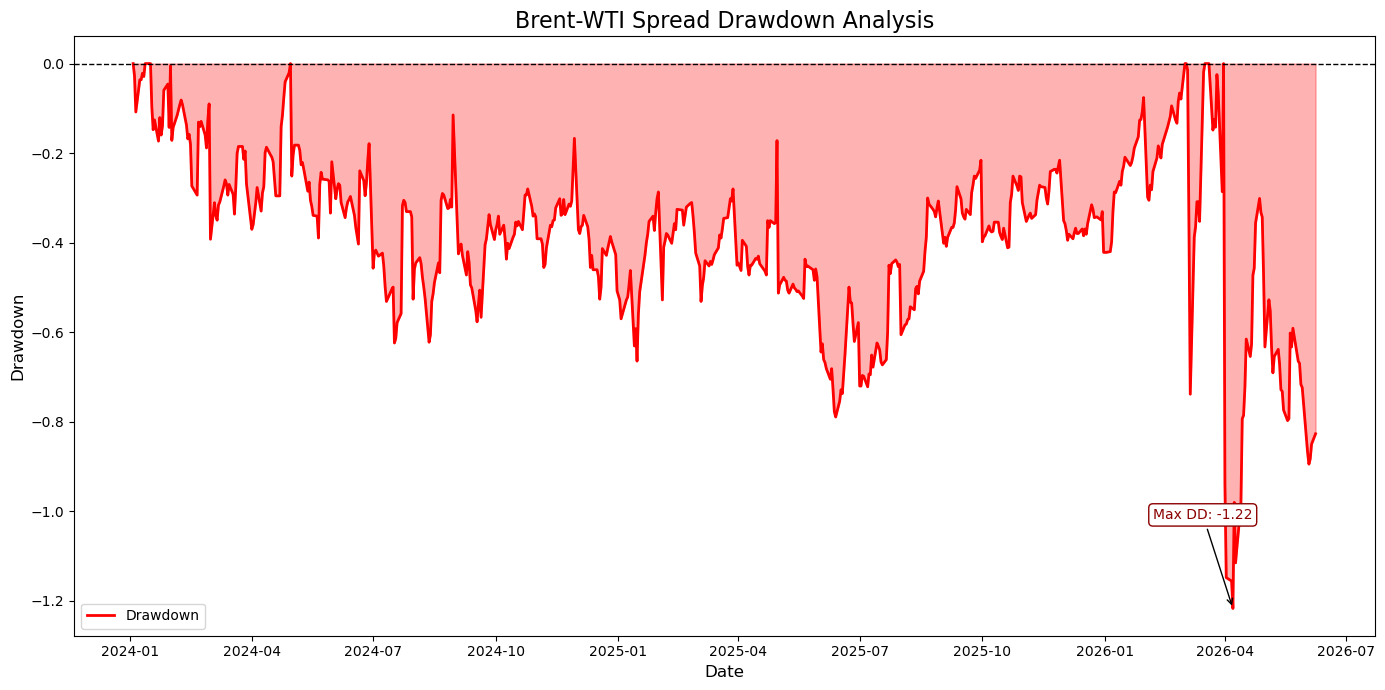

In [24]:
#############################################################################################################
# PLOT DRAWDOWNS
###############################################################################################################
plt.figure(figsize=(14,7))
# plot drawdowns
plt.plot(drawdowns, label='Drawdown', color='red', linewidth=2)
# Fill area under drawdown curve
plt.fill_between(drawdowns.index, drawdowns, 0, alpha=0.3, color='red')
# plot Zero line
plt.axhline(0, color='black', linestyle='--', linewidth=1)
# annotate max drawdown
min_idx = drawdowns.idxmin()
plt.annotate(f"Max DD: {drawdowns.min():.2f}",
             xy=(min_idx, drawdowns.min()),
             xytext=(min_idx - pd.Timedelta(days=60), drawdowns.min() + 0.2),
             arrowprops=dict(arrowstyle='->'),
             color='darkred', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))
# titles & axis labels 
plt.title('Brent-WTI Spread Drawdown Analysis', fontsize=16)
plt.xlabel('Date', fontsize =12)
plt.ylabel('Drawdown', fontsize=12)
#legend
plt.legend()
plt.tight_layout()
plt.show()



## Revised Talking Points

- The Brent-WTI spread has been in **persistent weakness since early 2024**, meaning the premium Brent typically commands over WTI has been consistently eroding
- The **April 2026 dislocation** is the most significant event in the series — the spread fell $1.22 below its peak, suggesting a sharp macro shock compressed the relationship dramatically
- The **failure to recover to peak levels** at any point in the 2-year window suggests this isn't just short-term noise — there's a structural story of Brent losing relative ground to WTI
- The **increasing volatility in 2026** vs the more gradual drawdown of 2024 points to the spread becoming increasingly sensitive to macro events, likely trade war/tariff driven rather than pure supply fundamentals
- **Without seeing the raw spread**, you can't say Brent traded below WTI — but you can say the Brent premium has been significantly and persistently squeezed throughout this period, which is itself notable given OPEC+ cuts were specifically designed to support Brent-linked crude prices